---
date: "2026-07-15"
date-modified: last-modified
format:
  html:
    toc: true
---

# The Lebesgue Integral

## 1\. The Fundamental Difference Between Riemann and Lebesgue Integrals

The transition from the traditional [Riemann integral]() to the modern **[Lebesgue integral]()** represents a profound shift in how mathematical analysis approaches the concept of measuring the "area under a curve." At its core, the difference between Riemann and Lebesgue integration lies in how the function's domain versus its range is partitioned.

* **Riemann's Idea (Partitioning the Domain):** To compute the Riemann integral of a bounded function $f: [a, b] \to \mathbb{R}$, we partition the **domain** $[a, b]$ into small subintervals $[x_{i-1}, x_i]$. We then approximate the function by choosing sample heights on each subinterval. Consequently, the elementary building blocks of the Riemann integral are **[step functions]()**, which take constant values on finite intervals of the real line.
* **Lebesgue's Idea (Partitioning the Range):** To compute the Lebesgue integral of $f: X \to \mathbb{R}$, we partition the **range** (or target space $\mathbb{R}$) into small horizontal intervals or bands $[y_{j-1}, y_j)$. We then group together *all* points in the domain where the function takes values inside each horizontal band by forming the preimage set:
  $$
  E_j = \left\{x \in X \;\middle|\; y_{j-1} \leq f(x) < y_j\right\} = f^{-1}([y_{j-1}, y_j))
  $$

Because preimages of horizontal bands can be scattered and disjoint across the entire domain, **the domain is not necessarily partitioned into intervals; rather, it is partitioned into arbitrary [measurable sets](measurable-sets.ipynb)** $E_1, E_2, \dots, E_n$. Therefore, the elementary building blocks of the Lebesgue integral are **[simple functions]()**—functions that take finitely many distinct values on measurable sets.

::: {.callout-note}
## Intuition: The Coin Counting Analogy
A famous analogy by Henri Lebesgue compares Riemann and Lebesgue integration to two different ways a merchant counts a pile of coins:

1. **The Riemann approach:** The merchant picks up the coins one by one in whatever order they happen to lie across the table and adds up their values sequentially. If the table is neatly arranged into smooth rows (continuous functions), this works well. However, if the coins are wildly scattered and scrambled, keeping track of the total becomes chaotic and breaks down.
2. **The Lebesgue approach:** The merchant first sorts the pile of coins by value—putting all the pennies into one pile ($E_1$), all the nickels into a second pile ($E_2$), all the dimes into a third pile ($E_3$), and all the quarters into a fourth pile ($E_4$). Once sorted by range values, the total amount is trivially calculated as $\sum c_k \cdot \text{(number of coins in pile } E_k\text{)}$. By grouping domain points according to their output values in the range, Lebesgue integration effortlessly handles highly discontinuous and erratic functions.
:::

<!-- CELL BREAK -->


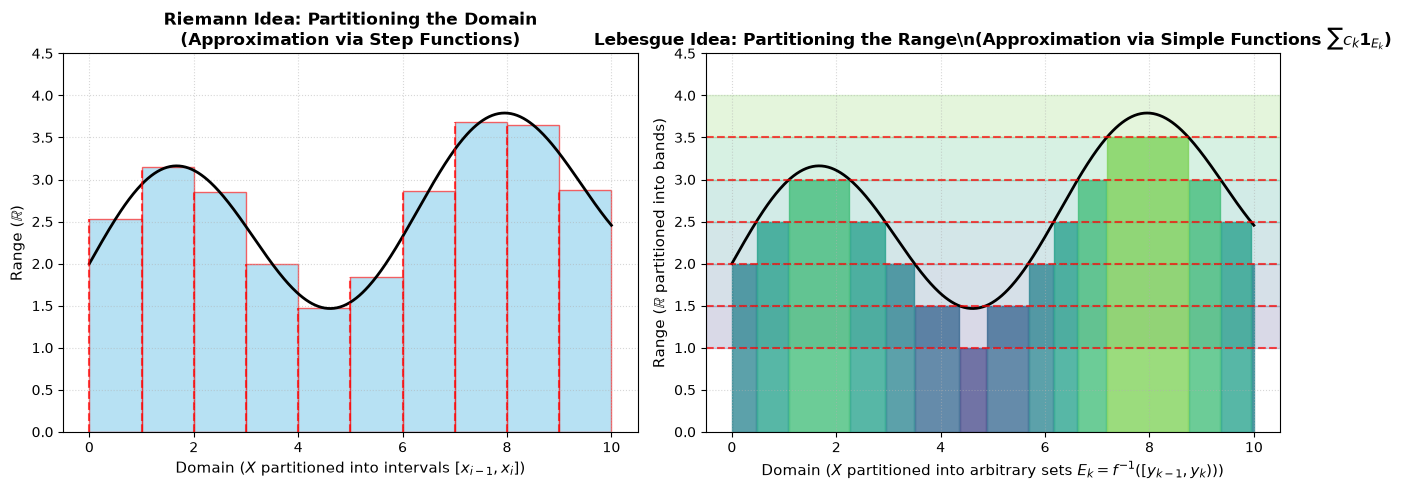

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define domain and function
x = np.linspace(0, 10, 500)
f = 2 + np.sin(x) + 0.1 * x

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Riemann Idea: Partitioning the domain into small intervals [x_{i-1}, x_i]
ax1.plot(x, f, 'k-', linewidth=2, label=r'$f(x)$')
n_intervals = 10
x_edges = np.linspace(0, 10, n_intervals + 1)
for i in range(n_intervals):
    x_mid = 0.5 * (x_edges[i] + x_edges[i+1])
    y_val = 2 + np.sin(x_mid) + 0.1 * x_mid
    ax1.add_patch(plt.Rectangle((x_edges[i], 0), x_edges[i+1] - x_edges[i], y_val,
                                facecolor='skyblue', edgecolor='red', alpha=0.6))
    ax1.vlines(x_edges[i], 0, y_val, color='red', linestyle='--', alpha=0.7)

ax1.set_title('Riemann Idea: Partitioning the Domain\n(Approximation via Step Functions)', fontsize=12, fontweight='bold')
ax1.set_xlabel(r'Domain ($X$ partitioned into intervals $[x_{i-1}, x_i]$)', fontsize=11)
ax1.set_ylabel(r'Range ($\mathbb{R}$)', fontsize=11)
ax1.set_ylim(0, 4.5)
ax1.grid(True, linestyle=':', alpha=0.5)

# 2. Lebesgue Idea: Partitioning the range into small bands [y_{j-1}, y_j]
ax2.plot(x, f, 'k-', linewidth=2, label=r'$f(x)$')
n_levels = 6
y_levels = np.linspace(1.0, 4.0, n_levels + 1)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, n_levels))

for j in range(n_levels):
    y_low = y_levels[j]
    y_high = y_levels[j+1]
    ax2.axhspan(y_low, y_high, color=colors[j], alpha=0.2, label=f'Level $c_{j+1}$')
    ax2.axhline(y_low, color='red', linestyle='--', alpha=0.7)
    
    # Highlight the preimage domain sets E_j where y_low <= f(x) < y_high
    mask = (f >= y_low) & (f < y_high)
    ax2.fill_between(x, 0, y_low, where=mask, color=colors[j], alpha=0.75)

ax2.set_title(r'Lebesgue Idea: Partitioning the Range\n(Approximation via Simple Functions $\sum c_k \mathbf{1}_{E_k}$)', fontsize=12, fontweight='bold')
ax2.set_xlabel(r'Domain ($X$ partitioned into arbitrary sets $E_k = f^{-1}([y_{k-1}, y_k))$)', fontsize=11)
ax2.set_ylabel(r'Range ($\mathbb{R}$ partitioned into bands)', fontsize=11)
ax2.set_ylim(0, 4.5)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()



## 2\. Simple Functions and Well-Definedness of Their Integral

To build the theory of the Lebesgue integral rigorously, we begin by defining integration on simple functions and proving that this definition is independent of the representation chosen.

Let $(X, \mathcal{M}, \mu)$ be a [measure space](measure.ipynb), where $X$ is a set, $\mathcal{M}$ is a [$\sigma$-algebra](sigma-algebra.ipynb) of subsets of $X$, and $\mu: \mathcal{M} \to [0, \infty]$ is a [measure](measure.ipynb).

**Definition 1 (Simple Function)**
A real-valued function $\psi: X \to \mathbb{R}$ is called a **simple function** if it can be written as a finite linear combination of **[indicator functions](measurable-functions.ipynb#key-examples-and-counterexamples)** of [measurable sets](measurable-sets.ipynb):
$$
\psi = \sum_{k=1}^n c_k \mathbf{1}_{E_k}
$$
where $c_1, c_2, \dots, c_n \in \mathbb{R}$ are real numbers and $E_1, E_2, \dots, E_n \in \mathcal{M}$ are measurable subsets of $X$.

[Note: By grouping identical coefficients together and decomposing the sets into their disjoint intersections, **we can always assume without loss of generality that the sets $E_1, \dots, E_n$ are pairwise disjoint** ($E_k \cap E_j = \emptyset$ for $k \neq j$). When the sets $E_k$ partition $X$ into disjoint sets corresponding to the distinct values of $\psi$, this is called the *canonical representation* of $\psi$.]{.aside}

**Definition 2 (Integral of a Nonnegative Simple Function)**
Let $\psi = \sum_{k=1}^n c_k \mathbf{1}_{E_k}$ be a nonnegative simple function on $(X, \mathcal{M}, \mu)$, assuming without loss of generality that $c_k \geq 0$ and the sets $E_k$ are pairwise disjoint. The **Lebesgue integral of $\psi$ with respect to $\mu$ over $X$** is defined to be:
$$
\int_X \psi \, d\mu := \sum_{k=1}^n c_k \mu(E_k)
$$
We adopt the standard measure-theoretic convention that $0 \cdot \infty = 0$. That is, if a simple function takes the value $c_k = 0$ on a set of infinite measure $\mu(E_k) = \infty$, that term contributes $0$ to the total summation.

For any measurable subset $A \in \mathcal{M}$, the integral of $\psi$ over $A$ is defined by integrating the simple function $\psi \cdot \mathbf{1}_A$ over $X$:
$$
\int_A \psi \, d\mu := \int_X (\psi \cdot \mathbf{1}_A) \, d\mu = \sum_{k=1}^n c_k \mu(A \cap E_k)
$$

**Theorem 1 (Well-Definedness of the Integral of Simple Functions)**
The Lebesgue integral of a nonnegative simple function is **well-defined**. That is, if $\psi$ admits two different representations as linear combinations of indicator functions of measurable sets:
$$
\psi = \sum_{k=1}^n c_k \mathbf{1}_{E_k} = \sum_{j=1}^m d_j \mathbf{1}_{F_j}
$$
then the resulting value of the integral is invariant under the choice of representation:
$$
\sum_{k=1}^n c_k \mu(E_k) = \sum_{j=1}^m d_j \mu(F_j)
$$

::: {.callout-tip collapse="true"}
## Proof of Theorem 1

We must prove that $\sum_{k=1}^n c_k \mu(E_k) = \sum_{j=1}^m d_j \mu(F_j)$.

**Step 1: Constructing a common refinement partition**
By adding terms with zero coefficients if necessary, we may assume without loss of generality that both collections of sets $\{E_k\}_{k=1}^n$ and $\{F_j\}_{j=1}^m$ form pairwise disjoint partitions of the entire space $X$:
$$
X = \bigcup_{k=1}^n E_k = \bigcup_{j=1}^m F_j
$$
Consider the family of all pairwise intersections $G_{k, j} = E_k \cap F_j$ for $1 \leq k \leq n$ and $1 \leq j \leq m$. Since the sets in each collection are disjoint, the collection $\{E_k \cap F_j\}_{k, j}$ forms a common refinement partition of $X$ consisting of pairwise disjoint measurable sets. In particular, each set $E_k$ and $F_j$ decomposes into disjoint unions:
$$
E_k = \bigcup_{j=1}^m (E_k \cap F_j) \quad \text{and} \quad F_j = \bigcup_{k=1}^n (E_k \cap F_j)
$$

**Step 2: Applying finite additivity of measure**
Because the measure $\mu$ is finitely additive over disjoint unions of measurable sets, we have:
$$
\mu(E_k) = \sum_{j=1}^m \mu(E_k \cap F_j) \quad \text{and} \quad \mu(F_j) = \sum_{k=1}^n \mu(E_k \cap F_j)
$$

**Step 3: Comparing coefficients on non-empty intersections**
If the intersection $E_k \cap F_j$ is non-empty, let $x \in E_k \cap F_j$. Evaluating both representations of $\psi$ at $x$ yields:
$$
\psi(x) = c_k = d_j
$$
Thus, whenever $\mu(E_k \cap F_j) > 0$, we must have $c_k = d_j$. (If $\mu(E_k \cap F_j) = 0$, both $c_k \mu(E_k \cap F_j)$ and $d_j \mu(E_k \cap F_j)$ equal zero by convention).

**Step 4: Equating the two double sums**
Substituting the disjoint decompositions of $\mu(E_k)$ and $\mu(F_j)$ into the two summations and reversing the order of summation yields:
$$
\begin{aligned}
\sum_{k=1}^n c_k \mu(E_k) &= \sum_{k=1}^n c_k \left(\sum_{j=1}^m \mu(E_k \cap F_j)\right) \\
&= \sum_{k=1}^n \sum_{j=1}^m c_k \mu(E_k \cap F_j) \\
&= \sum_{k=1}^n \sum_{j=1}^m d_j \mu(E_k \cap F_j) \\
&= \sum_{j=1}^m d_j \left(\sum_{k=1}^n \mu(E_k \cap F_j)\right) \\
&= \sum_{j=1}^m d_j \mu(F_j)
\end{aligned}
$$
Therefore, the integral is completely independent of the representation chosen. $\blacksquare$
:::

**Example 1 (The Dirichlet Function)**
Consider the classical **[Dirichlet function]()** $f: \mathbb{R} \to \mathbb{R}$ defined by the indicator function of the rational numbers $\mathbb{Q}$:
$$
f(x) = \mathbf{1}_{\mathbb{Q}}(x) = \begin{cases} 1 & x \in \mathbb{Q} \\ 0 & x \in \mathbb{Q}^c \end{cases}
$$
Since both the rational numbers $\mathbb{Q}$ and the irrational numbers $\mathbb{Q}^c$ are [Borel measurable sets](Borel-sets-and-measurability.ipynb) in $\mathbb{R}$, $f$ is a simple function with canonical representation:
$$
f = 1 \cdot \mathbf{1}_{\mathbb{Q}} + 0 \cdot \mathbf{1}_{\mathbb{Q}^c}
$$
With respect to the standard [Lebesgue measure](Lebesgue-measure.ipynb) $\mu$ on $\mathbb{R}$, because $\mathbb{Q}$ is a countable union of singleton points, its measure is zero ($\mu(\mathbb{Q}) = 0$). Hence, the Lebesgue integral of $f$ over $\mathbb{R}$ is easily computed as:
$$
\int_{\mathbb{R}} f \, d\mu = 1 \times \mu(\mathbb{Q}) + 0 \times \mu(\mathbb{Q}^c) = 1 \times 0 + 0 \times \infty = 0
$$
In stark contrast, the Riemann integral of $f$ over any interval $[a, b]$ does not exist because every subinterval contains both rational and irrational numbers, causing the upper Riemann sums ($1 \cdot (b-a)$) and lower Riemann sums ($0 \cdot (b-a)$) to never coincide.

<!-- CELL BREAK -->




## 3\. Properties of the Integral of Nonnegative Simple Functions

We now establish the fundamental algebraic and order properties of the Lebesgue integral when restricted to nonnegative simple functions.

**Proposition 1 (Basic Properties of Simple Function Integrals)**
Let $(X, \mathcal{M}, \mu)$ be a [measure space](measure.ipynb), and let $\varphi$ and $\psi$ be nonnegative simple functions on $X$.

1. **Linearity for positive combinations:** If $\alpha$ and $\beta$ are positive real numbers, then
   $$
   \int_X [\alpha \cdot \psi + \beta \cdot \varphi] \, d\mu = \alpha \cdot \int_X \psi \, d\mu + \beta \cdot \int_X \varphi \, d\mu
   $$
2. **Finite additivity over disjoint domains:** If $A$ and $B$ are disjoint [measurable subsets](measurable-sets.ipynb) of $X$, then
   $$
   \int_{A \cup B} \psi \, d\mu = \int_A \psi \, d\mu + \int_B \psi \, d\mu
   $$
3. **Invariance under almost everywhere equality:** In particular, if $X_0 \subseteq X$ is a measurable subset and its complement has [measure zero](measure.ipynb), $\mu(X \setminus X_0) = 0$, then
   $$
   \int_X \psi \, d\mu = \int_{X_0} \psi \, d\mu
   $$
4. **Monotonicity:** Furthermore, if $\psi \leq \varphi$ [almost everywhere](limits-of-measurable-functions.ipynb#convergence-and-equality-almost-everywhere) on $X$, then
   $$
   \int_X \psi \, d\mu \leq \int_X \varphi \, d\mu
   $$

::: {.callout-tip collapse="true"}
## Proof of Proposition 1

**Proof of Part (1): Linearity**
If either $\psi$ or $\varphi$ is strictly positive on a measurable set of infinite measure, then the linear combination $\alpha \cdot \psi + \beta \cdot \varphi$ also takes a positive value on that same set of infinite measure. Therefore, each side of equation (1) equals $\infty$. We may assume hereafter that both $\psi$ and $\varphi$ vanish outside a set of finite measure.

Let $\psi = \sum_{k=1}^n c_k \mathbf{1}_{E_k}$ and $\varphi = \sum_{j=1}^m d_j \mathbf{1}_{F_j}$ be representations where $\{E_k\}_{k=1}^n$ and $\{F_j\}_{j=1}^m$ form pairwise disjoint partitions of $X$. Then the collection of intersections $\{E_k \cap F_j\}_{k, j}$ forms a disjoint partition of $X$, and for any $x \in E_k \cap F_j$, the linear combination evaluates to:
$$
(\alpha \cdot \psi + \beta \cdot \varphi)(x) = \alpha c_k + \beta d_j
$$
Since this is a valid representation of the simple function $\alpha \cdot \psi + \beta \cdot \varphi$, and by Theorem 1 the integral is independent of the representation, we compute:
$$
\begin{aligned}
\int_X (\alpha \cdot \psi + \beta \cdot \varphi) \, d\mu &= \sum_{k=1}^n \sum_{j=1}^m (\alpha c_k + \beta d_j) \mu(E_k \cap F_j) \\
&= \alpha \sum_{k=1}^n c_k \sum_{j=1}^m \mu(E_k \cap F_j) + \beta \sum_{j=1}^m d_j \sum_{k=1}^n \mu(E_k \cap F_j) \\
&= \alpha \sum_{k=1}^n c_k \mu(E_k) + \beta \sum_{j=1}^m d_j \mu(F_j) \\
&= \alpha \int_X \psi \, d\mu + \beta \int_X \varphi \, d\mu
\end{aligned}
$$

**Proof of Part (2): Finite Additivity over Domains**
Let $A, B \subseteq X$ be disjoint measurable subsets. By the elementary properties of indicator functions on disjoint sets, we have $\mathbf{1}_{A \cup B} = \mathbf{1}_A + \mathbf{1}_B$. Multiplying by the simple function $\psi$ yields:
$$
\psi \cdot \mathbf{1}_{A \cup B} = \psi \cdot \mathbf{1}_A + \psi \cdot \mathbf{1}_B
$$
Since $\psi \cdot \mathbf{1}_A$ and $\psi \cdot \mathbf{1}_B$ are both nonnegative simple functions, we apply the linearity established in Part (1) (with $\alpha = \beta = 1$) to obtain:
$$
\begin{aligned}
\int_{A \cup B} \psi \, d\mu &:= \int_X (\psi \cdot \mathbf{1}_{A \cup B}) \, d\mu \\
&= \int_X (\psi \cdot \mathbf{1}_A + \psi \cdot \mathbf{1}_B) \, d\mu \\
&= \int_X (\psi \cdot \mathbf{1}_A) \, d\mu + \int_X (\psi \cdot \mathbf{1}_B) \, d\mu \\
&= \int_A \psi \, d\mu + \int_B \psi \, d\mu
\end{aligned}
$$

**Proof of Part (3): Invariance under Almost Everywhere Equality**
Let $\psi = \sum_{k=1}^n c_k \mathbf{1}_{E_k}$ be the simple function. By definition, integrating over $X_0$ means integrating the product $\psi \cdot \mathbf{1}_{X_0}$ over $X$. We expand this product:
$$
\psi \cdot \mathbf{1}_{X_0} = \left(\sum_{k=1}^n c_k \mathbf{1}_{E_k}\right) \cdot \mathbf{1}_{X_0} = \sum_{k=1}^n c_k \mathbf{1}_{E_k \cap X_0}
$$
Taking the Lebesgue integral yields:
$$
\int_{X_0} \psi \, d\mu := \int_X (\psi \cdot \mathbf{1}_{X_0}) \, d\mu = \sum_{k=1}^n c_k \mu(E_k \cap X_0)
$$
Now, observe that each measurable set $E_k$ can be partitioned into its intersection with $X_0$ and its intersection with the null complement $X \setminus X_0$:
$$
E_k = (E_k \cap X_0) \cup (E_k \setminus X_0)
$$
Since $E_k \setminus X_0 = E_k \setminus (X \setminus (X \setminus X_0)) \subseteq X \setminus X_0$, monotonicity of measure implies:
$$
0 \leq \mu(E_k \setminus X_0) \leq \mu(X \setminus X_0) = 0 \implies \mu(E_k \setminus X_0) = 0
$$
By finite additivity over disjoint sets, we compute the measure of $E_k$:
$$
\mu(E_k) = \mu(E_k \cap X_0) + \mu(E_k \setminus X_0) = \mu(E_k \cap X_0) + 0 = \mu(E_k \cap X_0)
$$
Substituting $\mu(E_k \cap X_0) = \mu(E_k)$ directly back into our integral formula gives:
$$
\int_{X_0} \psi \, d\mu = \sum_{k=1}^n c_k \mu(E_k \cap X_0) = \sum_{k=1}^n c_k \mu(E_k) = \int_X \psi \, d\mu
$$

**Proof of Part (4): Monotonicity**
Suppose $\psi \leq \varphi$ almost everywhere on $X$. Define the subset where the inequality holds exactly:
$$
X_0 = \{x \in X \mid \psi(x) \leq \varphi(x)\}
$$
By hypothesis, $X_0$ is measurable and $\mu(X \setminus X_0) = 0$. Applying Part (3) to both $\psi$ and $\varphi$, we know that:
$$
\int_X \psi \, d\mu = \int_{X_0} \psi \, d\mu \quad \text{and} \quad \int_X \varphi \, d\mu = \int_{X_0} \varphi \, d\mu
$$
On the set $X_0$, the function $\varphi - \psi$ is a well-defined, non-negative simple function since $\varphi(x) - \psi(x) \geq 0$ for all $x \in X_0$. Because the coefficients and measures of a nonnegative simple function are all non-negative, its integral over $X_0$ is non-negative:
$$
\int_{X_0} (\varphi - \psi) \, d\mu \geq 0
$$
By the linearity property from Part (1) applied over the domain $X_0$, we conclude:
$$
\int_{X_0} \varphi \, d\mu - \int_{X_0} \psi \, d\mu = \int_{X_0} (\varphi - \psi) \, d\mu \geq 0 \implies \int_X \psi \, d\mu \leq \int_X \varphi \, d\mu \quad \blacksquare
$$
:::



## 4\. The Lebesgue Integral of Nonnegative Measurable Functions

Having established the integral for nonnegative [simple functions](measurable-functions.ipynb) in Sections 2 and 3, we now extend the definition of the Lebesgue integral to arbitrary nonnegative [measurable functions](measurable-functions.ipynb). The key idea is to approximate a general nonnegative measurable function from below by nonnegative simple functions and then take the supremum over all such approximations.

Let $(X, \mathcal{M}, \mu)$ be a [measure space](measure.ipynb), where $X$ is a set, $\mathcal{M}$ is a [$\sigma$-algebra](sigma-algebra.ipynb) of subsets of $X$, and $\mu: \mathcal{M} \to [0, \infty]$ is a [measure](measure.ipynb).

**Definition 2 (Lebesgue Integral of a Nonnegative Measurable Function)**
Let $f: X \to [0, \infty]$ be a nonnegative [measurable function](measurable-functions.ipynb). The **Lebesgue integral** of $f$ over $X$ with respect to $\mu$ is defined as:
$$
\int_X f \, d\mu := \sup_{\substack{0 \leq \varphi \leq f \\ \varphi \text{ simple}}} \int_X \varphi \, d\mu
$$
where the supremum is taken over all nonnegative simple functions $\varphi$ satisfying $0 \leq \varphi(x) \leq f(x)$ for every $x \in X$.

More generally, for a [measurable subset](measurable-sets.ipynb) $E \in \mathcal{M}$, we define:
$$
\int_E f \, d\mu := \int_X f \cdot \mathbf{1}_E \, d\mu = \sup_{\substack{0 \leq \varphi \leq f \cdot \mathbf{1}_E \\ \varphi \text{ simple}}} \int_X \varphi \, d\mu
$$

::: {.callout-note}
## Intuition: Approximation from Below
The definition captures the geometric idea of approximating the "area under the curve" of $f$ from below using "staircase" functions. Each simple function $\varphi$ with $0 \leq \varphi \leq f$ represents a particular staircase that fits underneath the graph of $f$. The integral of $f$ is the *best possible* (i.e., largest) value obtainable from any such approximation. This mirrors the construction of the Riemann integral using lower sums, but with the crucial advantage that the approximating functions are allowed to take constant values on arbitrary [measurable sets](measurable-sets.ipynb)—not just on intervals—making the definition applicable to a far broader class of functions.
:::

::: {.callout-warning}
## Consistency with Simple Functions
It is essential to verify that Definition 2 is consistent with the integral defined in Section 2 for simple functions. That is, if $f$ itself is a nonnegative simple function, then the supremum in Definition 2 should equal the value given by the formula in Definition 1. This follows immediately because if $f = \sum_{k=1}^n c_k \mathbf{1}_{E_k}$ is a nonnegative simple function, then $f$ itself is among the simple functions $\varphi$ satisfying $0 \leq \varphi \leq f$, and by the monotonicity property of simple function integrals (Proposition 1, Part 4), $f$ achieves the supremum.
:::

<!-- CELL BREAK -->





## 5\. Properties of the Integral of Nonnegative Measurable Functions

The Lebesgue integral of nonnegative [measurable functions](measurable-functions.ipynb) inherits the key structural properties from the integral of simple functions. The following proposition establishes the fundamental algebraic, order, and domain-invariance properties.

Let $(X, \mathcal{M}, \mu)$ be a [measure space](measure.ipynb), and let $g, h: X \to [0, \infty]$ be nonnegative [measurable functions](measurable-functions.ipynb) on $X$. Let $X_0 \in \mathcal{M}$ be a [measurable subset](measurable-sets.ipynb) of $X$, and let $\alpha$ be a positive real number.

**Proposition 2 (Basic Properties of the Integral of Nonneg. Measurable Functions)**

1. **Positive homogeneity:** If $\alpha \geq 0$ is a nonnegative real number, then
   $$
   \int_X \alpha \cdot g \, d\mu = \alpha \cdot \int_X g \, d\mu
   $$
2. **Monotonicity:** If $g \leq h$ [almost everywhere](limits-of-measurable-functions.ipynb#convergence-and-equality-almost-everywhere) on $X$, then
   $$
   \int_X g \, d\mu \leq \int_X h \, d\mu
   $$
3. **Domain invariance under null sets:** If $\mu(X \setminus X_0) = 0$, then
   $$
   \int_X g \, d\mu = \int_{X_0} g \, d\mu
   $$

::: {.callout-tip collapse="true"}
## Proof of Proposition 2

**Proof of Part (1): Positive Homogeneity**
If $\alpha = 0$, both sides equal $0$ and the result is trivial. Assume $\alpha > 0$. We must show:
$$
\sup_{\substack{0 \leq \varphi \leq \alpha g \\ \varphi \text{ simple}}} \int_X \varphi \, d\mu = \alpha \cdot \sup_{\substack{0 \leq \psi \leq g \\ \psi \text{ simple}}} \int_X \psi \, d\mu
$$
Observe that the mapping $\psi \mapsto \alpha \psi$ establishes a bijection between the set of nonnegative simple functions satisfying $0 \leq \psi \leq g$ and those satisfying $0 \leq \varphi \leq \alpha g$. Indeed, if $0 \leq \psi \leq g$, then $0 \leq \alpha \psi \leq \alpha g$, and conversely if $0 \leq \varphi \leq \alpha g$, then $0 \leq \frac{1}{\alpha}\varphi \leq g$. By the linearity of the simple function integral (Proposition 1, Part 1), $\int_X \alpha \psi \, d\mu = \alpha \int_X \psi \, d\mu$. Taking the supremum over all such $\psi$ completes the proof.

**Proof of Part (2): Monotonicity**
Suppose $g \leq h$ almost everywhere on $X$. Let $\varphi$ be any nonnegative simple function with $0 \leq \varphi \leq g$. Since $g \leq h$ a.e., we have $\varphi \leq h$ a.e. as well. Define $X_0 = \{x \in X \mid \varphi(x) \leq h(x)\}$. Then $\mu(X \setminus X_0) = 0$. Consider the nonnegative simple function $\varphi' = \varphi \cdot \mathbf{1}_{X_0}$; this satisfies $0 \leq \varphi' \leq h$ everywhere. By the invariance of the simple function integral under null sets (Proposition 1, Part 3):
$$
\int_X \varphi \, d\mu = \int_{X_0} \varphi \, d\mu = \int_X \varphi' \, d\mu \leq \sup_{\substack{0 \leq \psi \leq h \\ \psi \text{ simple}}} \int_X \psi \, d\mu = \int_X h \, d\mu
$$
Since this holds for every admissible $\varphi$, taking the supremum over all such $\varphi$ yields $\int_X g \, d\mu \leq \int_X h \, d\mu$.

**Proof of Part (3): Domain Invariance under Null Sets**
Suppose $\mu(X \setminus X_0) = 0$. We prove both inequalities.

**$(\leq)$:** Since $g \cdot \mathbf{1}_{X_0} \leq g$ everywhere, every simple function $\varphi$ satisfying $0 \leq \varphi \leq g \cdot \mathbf{1}_{X_0}$ also satisfies $0 \leq \varphi \leq g$. Therefore $\int_{X_0} g \, d\mu \leq \int_X g \, d\mu$.

**$(\geq)$:** Conversely, let $\varphi$ be any nonnegative simple function with $0 \leq \varphi \leq g$. Consider the restricted simple function $\varphi \cdot \mathbf{1}_{X_0}$, which satisfies $0 \leq \varphi \cdot \mathbf{1}_{X_0} \leq g \cdot \mathbf{1}_{X_0}$. By the null-set invariance for simple function integrals (Proposition 1, Part 3):
$$
\int_X \varphi \, d\mu = \int_{X_0} \varphi \, d\mu = \int_X (\varphi \cdot \mathbf{1}_{X_0}) \, d\mu \leq \int_{X_0} g \, d\mu
$$
Taking the supremum over all such $\varphi$ gives $\int_X g \, d\mu \leq \int_{X_0} g \, d\mu$.

Combining both inequalities, $\int_X g \, d\mu = \int_{X_0} g \, d\mu$. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Properties Mirror Simple Function Properties
Proposition 2 shows that the three core properties of the simple function integral (scaling, ordering, and insensitivity to null sets) carry over seamlessly to the much larger class of nonnegative measurable functions. This is a direct consequence of the supremum-based definition: each property is "inherited" because the simple function approximations already satisfy it, and the supremum preserves these relationships. The monotonicity property, in particular, is essential for establishing the major convergence theorems (such as the [Monotone Convergence Theorem]() and [Fatou's Lemma]()) that form the backbone of Lebesgue integration theory.
:::





## 6\. Chebyshev's Inequality

A powerful and immediate consequence of the supremum-based definition of the Lebesgue integral is **Chebyshev's inequality** (also known as **Markov's inequality** in the probability literature). It provides an upper bound on the "size" of the level set where a nonnegative function exceeds a given threshold, purely in terms of its integral.

Let $(X, \mathcal{M}, \mu)$ be a [measure space](measure.ipynb), let $f: X \to [0, \infty]$ be a nonnegative [measurable function](measurable-functions.ipynb), and let $\lambda > 0$.

**Proposition 3 (Chebyshev's Inequality)**
Define the level set $E_\lambda = \{x \in X \mid f(x) \geq \lambda\}$. Then:
$$
\mu(E_\lambda) \leq \frac{1}{\lambda} \int_X f \, d\mu
$$

::: {.callout-tip collapse="true"}
## Proof of Proposition 3

Define the nonnegative simple function $\varphi = \lambda \cdot \mathbf{1}_{E_\lambda}$, where $E_\lambda = \{x \in X \mid f(x) \geq \lambda\}$. Since $f(x) \geq \lambda$ for all $x \in E_\lambda$ and $\varphi(x) = 0$ for $x \notin E_\lambda$, we have $0 \leq \varphi \leq f$ everywhere on $X$.

By the definition of the Lebesgue integral as a supremum over all admissible simple functions (Definition 2), and using the monotonicity of the supremum, we obtain:
$$
\int_X f \, d\mu = \sup_{\substack{0 \leq \psi \leq f \\ \psi \text{ simple}}} \int_X \psi \, d\mu \geq \int_X \varphi \, d\mu = \lambda \cdot \mu(E_\lambda)
$$
Dividing both sides by $\lambda > 0$ yields the result:
$$
\mu(E_\lambda) \leq \frac{1}{\lambda} \int_X f \, d\mu \qquad \blacksquare
$$
:::

::: {.callout-note}
## Intuition: Geometric Meaning
Chebyshev's inequality has a simple geometric interpretation. If $f$ is nonnegative and its integral (the "total area under the curve") is finite, then the set where $f$ is large cannot itself be too large. More precisely, the measure of the region where $f \geq \lambda$ is at most $\frac{1}{\lambda}$ times the total integral. Think of it as a "conservation of area" argument: a function with a fixed total area cannot be simultaneously large *and* spread out over a large set.
:::

::: {.callout-note}
## Connection to Probability Theory
In the special setting of [probability theory](), where $(X, \mathcal{M}, \mu) = (\Omega, \mathcal{F}, P)$ is a [probability space]() and $f = X$ is a nonnegative [random variable](random-variables.ipynb), Chebyshev's inequality takes the familiar probabilistic form:
$$
P(X \geq \lambda) \leq \frac{1}{\lambda}\, E(X)
$$
where $E(X) = \int_\Omega X \, dP$ is the [expectation](expectation.ipynb) of $X$. This is a foundational tool in probability for bounding tail probabilities.
:::

<!-- CELL BREAK -->





## 7\. Finiteness and Vanishing of the Integral

Using Chebyshev's inequality and the properties established in Sections 5 and 6, we derive several important consequences about when the Lebesgue integral is finite and what it means for the integral to vanish.

Let $(X, \mathcal{M}, \mu)$ be a [measure space](measure.ipynb) and let $f: X \to [0, \infty]$ be a nonnegative [measurable function](measurable-functions.ipynb).

**Corollary 1 (Finiteness and Vanishing Properties)**

1. **(a)** If $\displaystyle\int_X f \, d\mu < \infty$, then $f < \infty$ [almost everywhere](limits-of-measurable-functions.ipynb#convergence-and-equality-almost-everywhere).
2. **(b)** If $f$ is bounded (i.e., $f \leq M$ for some constant $M$) and $\mu(X) < \infty$, then $\displaystyle\int_X f \, d\mu < \infty$.
3. **(c)** If $\displaystyle\int_X f \, d\mu = 0$, then $f = 0$ almost everywhere.
4. **(d)** If $f = 0$ almost everywhere, then $\displaystyle\int_X f \, d\mu = 0$.

::: {.callout-tip collapse="true"}
## Proof of Corollary 1

**Proof of Part (a):**
Define the set where $f$ is infinite: $E_\infty = \{x \in X \mid f(x) = \infty\}$. For each $n \in \mathbb{N}$, define $E_n = \{x \in X \mid f(x) \geq n\}$. Then $E_\infty = \bigcap_{n=1}^\infty E_n$.

By Chebyshev's inequality (Proposition 3), for each $n$:
$$
\mu(E_n) \leq \frac{1}{n} \int_X f \, d\mu
$$
Since $\int_X f \, d\mu < \infty$, taking $n \to \infty$ gives $\mu(E_n) \to 0$. Because $E_n$ is a decreasing sequence of [measurable sets](measurable-sets.ipynb) with $\mu(E_1) \leq \frac{1}{1}\int_X f \, d\mu < \infty$, by the [continuity of measure from above](continuity-of-measure.ipynb):
$$
\mu(E_\infty) = \lim_{n \to \infty} \mu(E_n) = 0
$$
Hence $f < \infty$ almost everywhere.

**Proof of Part (b):**
Since $f \leq M$ everywhere and $f$ is nonnegative, the simple function $\varphi = M \cdot \mathbf{1}_X$ satisfies $0 \leq f \leq \varphi$. By the monotonicity of the integral (Proposition 2, Part 2):
$$
\int_X f \, d\mu \leq \int_X M \cdot \mathbf{1}_X \, d\mu = M \cdot \mu(X) < \infty
$$

**Proof of Part (c):**
Assume $\int_X f \, d\mu = 0$. We must show $f = 0$ a.e., i.e., that $\mu(\{x : f(x) > 0\}) = 0$.

Suppose for contradiction that $\mu(E) > 0$, where $E = \{x \in X \mid f(x) > 0\}$. Write $E$ as a countable union of ascending measurable sets:
$$
E = \{x : f(x) > 0\} = \bigcup_{n=1}^\infty \underbrace{\left\{x : f(x) > \tfrac{1}{n}\right\}}_{E_n}
$$
Since $E_1 \subseteq E_2 \subseteq E_3 \subseteq \cdots$ is an ascending sequence, by the [continuity of measure from below](continuity-of-measure.ipynb):
$$
\mu(E) = \lim_{n \to \infty} \mu(E_n)
$$
Because $\mu(E) > 0$, there must exist some $n_0 \in \mathbb{N}$ such that $\mu(E_{n_0}) > 0$.

Now consider the nonnegative simple function $\varphi = \frac{1}{n_0} \cdot \mathbf{1}_{E_{n_0}}$. On the set $E_{n_0}$, we have $f(x) > \frac{1}{n_0} = \varphi(x)$, and outside $E_{n_0}$, $\varphi(x) = 0 \leq f(x)$. Therefore $0 \leq \varphi \leq f$. By the definition of the Lebesgue integral:
$$
\int_X f \, d\mu \geq \int_X \varphi \, d\mu = \frac{1}{n_0} \cdot \mu(E_{n_0}) > 0
$$
This contradicts $\int_X f \, d\mu = 0$. Therefore $\mu(E) = 0$ and $f = 0$ a.e.

**Proof of Part (d):**
Assume $f = 0$ almost everywhere. We must show $\int_X f \, d\mu = 0$.

By definition, $\int_X f \, d\mu = \sup_{0 \leq \varphi \leq f,\, \varphi \text{ simple}} \int_X \varphi \, d\mu$. It suffices to show that $\int_X \varphi \, d\mu = 0$ for every nonnegative simple function $\varphi$ satisfying $0 \leq \varphi \leq f$.

Let $X_0 = \{x \in X \mid f(x) = 0\}$. Since $f = 0$ a.e., we have $\mu(X_0^c) = 0$, where $X_0^c = X \setminus X_0$.

Let $\varphi = \sum_{k=1}^n c_k \mathbf{1}_{E_k}$ be any nonnegative simple function with $0 \leq \varphi \leq f$. For any $x \in X_0$, we have $f(x) = 0$, so $\varphi(x) = 0$. This means that if $c_k > 0$, then $E_k \subseteq X_0^c$. By the [monotonicity of measure](measure.ipynb), $\mu(E_k) \leq \mu(X_0^c) = 0$, so $\mu(E_k) = 0$ for every $k$ with $c_k > 0$.

Therefore:
$$
\int_X \varphi \, d\mu = \sum_{k=1}^n c_k \cdot \mu(E_k) = 0
$$
Since every admissible simple function integrates to zero, the supremum is also zero:
$$
\int_X f \, d\mu = \sup_{\substack{0 \leq \varphi \leq f \\ \varphi \text{ simple}}} 0 = 0 \qquad \blacksquare
$$
:::

::: {.callout-note}
## Intuition: What These Results Mean
Parts (c) and (d) together establish a powerful characterization: for nonnegative measurable functions, **the integral vanishes if and only if the function is zero almost everywhere**. This is a uniquely Lebesgue-theoretic result—it has no Riemann analogue—and it reflects the fundamental principle that the Lebesgue integral is "blind" to sets of measure zero. Part (a) tells us that an integrable nonnegative function cannot blow up to infinity on any set of positive measure. Part (b) provides a simple sufficient condition for integrability: bounded functions on finite measure spaces are always integrable.
:::





## 8\. Interchanging Limits and Integrals: The Central Question

We have established that the [pointwise limit](limits-of-measurable-functions.ipynb) of a sequence of [measurable functions](measurable-functions.ipynb) is again measurable. A natural and fundamental question arises: if $(f_n)_{n=1}^\infty$ is a sequence of nonnegative measurable functions converging almost everywhere to $f$, does it follow that

$$
\lim_{n \to \infty} \int_X f_n \, d\mu = \int_X f \, d\mu \quad \text{?}
$$

**In general, the answer is no.** The interchange of limits and integrals does not hold without additional hypotheses. A simple counterexample is $f_n = n \cdot \mathbf{1}_{(0, 1/n)}$ on $(\mathbb{R}, \mathcal{L}, \mu)$: each $f_n$ has integral $1$, but $f_n \to 0$ pointwise, so $\int f = 0 \neq 1 = \lim \int f_n$.

However, the interchange *does* hold under two important sets of conditions, which constitute the cornerstones of Lebesgue integration theory:

1. **The [Monotone Convergence Theorem]() (MCT):** If $f_n \geq 0$ and $f_n \nearrow f$ (i.e., the sequence is nonnegative and monotonically increasing to $f$), then
   $$
   \lim_{n \to \infty} \int_X f_n \, d\mu = \int_X f \, d\mu
   $$

2. **The [Dominated Convergence Theorem]() (DCT — Lebesgue's Theorem):** If $f_n \to f$ [almost everywhere](limits-of-measurable-functions.ipynb#convergence-and-equality-almost-everywhere), and there exists an integrable dominating function $g \geq 0$ with $\int_X g \, d\mu < \infty$ such that $|f_n| \leq g$ for all $n$, then
   $$
   \lim_{n \to \infty} \int_X f_n \, d\mu = \int_X f \, d\mu
   $$

A closely related tool is **[Fatou's Lemma]()**, which provides a one-sided inequality without the monotonicity or domination hypotheses:
$$
\int_X \liminf_{n \to \infty} f_n \, d\mu \leq \liminf_{n \to \infty} \int_X f_n \, d\mu
$$

::: {.callout-note}
## Intuition: Why Extra Conditions Are Needed
The counterexample $f_n = n \cdot \mathbf{1}_{(0, 1/n)}$ shows that a sequence can concentrate its "mass" into a shrinking region, keeping the integral constant while the pointwise limit vanishes. The MCT prevents this by requiring the sequence to increase monotonically—mass cannot redistribute or escape to infinity. The DCT prevents it by bounding the entire sequence by an integrable function—no individual $f_n$ can concentrate too much mass anywhere. These convergence theorems will be developed in detail in subsequent notes.
:::

<!-- CELL BREAK -->





## 9\. Equivalence of the Riemann and Lebesgue Integrals for Continuous Functions

A natural question when introducing the Lebesgue integral is whether it agrees with the classical [Riemann integral]() on functions where both are defined. The following proposition confirms that for nonnegative continuous functions on a closed bounded interval, the two integrals coincide.

Let $\mu$ denote the [Lebesgue measure](Lebesgue-measure.ipynb) on $\mathbb{R}$.

**Proposition 4 (Riemann = Lebesgue for Continuous Functions)**
Let $f: [a, b] \to \mathbb{R}$ be a continuous function with $f \geq 0$. Then the Lebesgue integral of $f$ over $[a, b]$ equals the Riemann integral:
$$
\int_{[a,b]} f \, d\mu = R(f) := \lim_{\|P\| \to 0} \sum_{i=0}^{n-1} f(x_i^*) \, \Delta x_i
$$
where $P: a = x_0 < x_1 < \cdots < x_n = b$ is a partition of $[a, b]$, $x_i^* \in [x_i, x_{i+1}]$ are sample points, $\Delta x_i = x_{i+1} - x_i$, and $\|P\| = \max_i |\Delta x_i|$ is the mesh of the partition.

::: {.callout-tip collapse="true"}
## Proof of Proposition 4

**Step 1: $R(f) \leq \int_{[a,b]} f \, d\mu$**

For any partition $P: a = x_0 < x_1 < \cdots < x_n = b$, define the lower simple function:
$$
c_i = \min_{x \in [x_i, x_{i+1}]} f(x), \qquad \varphi_P = \sum_{i=0}^{n-1} c_i \cdot \mathbf{1}_{[x_i, x_{i+1})}
$$
Since $f$ is continuous on the compact interval $[x_i, x_{i+1}]$, the minimum is attained by the [extreme value theorem](). By construction, $0 \leq \varphi_P(x) \leq f(x)$ for all $x \in [a, b)$, so $\varphi_P$ is an admissible simple function in the definition of $\int_{[a,b]} f \, d\mu$. Therefore:
$$
\int_{[a,b]} f \, d\mu \geq \int_{[a,b]} \varphi_P \, d\mu = \sum_{i=0}^{n-1} c_i \cdot \mu\big([x_i, x_{i+1})\big) = \sum_{i=0}^{n-1} c_i \, \Delta x_i
$$

Since $f$ is continuous on the compact set $[a, b]$, it is [uniformly continuous](uniform-continuity.ipynb). For any $\varepsilon > 0$, there exists $\delta > 0$ such that:
$$
|x - y| < \delta \implies |f(x) - f(y)| < \varepsilon
$$
Choose any partition $P$ with $\|P\| = \max_i |\Delta x_i| < \delta$, and let $x_i^*$ be any sample point in $[x_i, x_{i+1}]$. Since $c_i = f(\hat{x}_i)$ for some $\hat{x}_i \in [x_i, x_{i+1}]$ where the minimum is attained, and both $x_i^*$ and $\hat{x}_i$ lie in the same subinterval of length less than $\delta$:
$$
|f(x_i^*) - c_i| = |f(x_i^*) - f(\hat{x}_i)| < \varepsilon
$$
Therefore:
$$
\left|\sum_{i=0}^{n-1} f(x_i^*) \, \Delta x_i - \sum_{i=0}^{n-1} c_i \, \Delta x_i\right| \leq \sum_{i=0}^{n-1} |\Delta x_i| \cdot |f(x_i^*) - c_i| < \varepsilon \sum_{i=0}^{n-1} |\Delta x_i| = \varepsilon(b - a)
$$
Since $\varepsilon > 0$ was arbitrary and $\sum c_i \, \Delta x_i \leq \int_{[a,b]} f \, d\mu$ for every partition, taking $\|P\| \to 0$ yields:
$$
R(f) = \lim_{\|P\| \to 0} \sum_{i=0}^{n-1} f(x_i^*) \, \Delta x_i \leq \int_{[a,b]} f \, d\mu
$$

**Step 2: $\int_{[a,b]} f \, d\mu \leq R(f)$**

For the reverse inequality, define the upper simple function for each partition $P$:
$$
M_i = \max_{x \in [x_i, x_{i+1}]} f(x), \qquad \psi_P = \sum_{i=0}^{n-1} M_i \cdot \mathbf{1}_{[x_i, x_{i+1})}
$$
Again by the extreme value theorem applied to $f$ on each compact subinterval, the maximum is attained. By construction, $f(x) \leq \psi_P(x)$ for all $x \in [a, b)$. By the monotonicity of the Lebesgue integral (Proposition 2, Part 2):
$$
\int_{[a,b]} f \, d\mu \leq \int_{[a,b]} \psi_P \, d\mu = \sum_{i=0}^{n-1} M_i \, \Delta x_i
$$

By the same uniform continuity argument as in Step 1, for any $\varepsilon > 0$ and any partition with $\|P\| < \delta$:
$$
\left|\sum_{i=0}^{n-1} M_i \, \Delta x_i - \sum_{i=0}^{n-1} f(x_i^*) \, \Delta x_i\right| < \varepsilon(b - a)
$$
Taking $\|P\| \to 0$:
$$
\int_{[a,b]} f \, d\mu \leq \lim_{\|P\| \to 0} \sum_{i=0}^{n-1} M_i \, \Delta x_i = R(f)
$$

**Conclusion:**
Combining Steps 1 and 2, we obtain $R(f) = \int_{[a,b]} f \, d\mu$. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Lower and Upper Squeezing
The proof sandwiches the Lebesgue integral between lower Riemann sums (which use minima on subintervals) and upper Riemann sums (which use maxima). Uniform continuity ensures that both the lower and upper sums converge to the same limit — the Riemann integral — as the partition becomes finer. The lower sums bound $\int f$ from below because they define admissible simple functions in the supremum definition; the upper sums bound $\int f$ from above by the monotonicity of the Lebesgue integral.
:::

::: {.callout-warning}
## Extension to Signed Continuous Functions
Proposition 4 is stated for nonnegative continuous functions because our definition of the Lebesgue integral (Definition 2) currently only covers nonneg functions. The result extends to arbitrary continuous $f: [a, b] \to \mathbb{R}$ once the Lebesgue integral is defined for signed functions via $\int f \, d\mu = \int f^+ \, d\mu - \int f^- \, d\mu$, where $f^+ = \max(f, 0)$ and $f^- = \max(-f, 0)$. Since both $f^+$ and $f^-$ are continuous and nonneg, the proposition applies to each, and linearity gives $R(f) = \int_{[a,b]} f \, d\mu$ for all continuous $f$.
:::





## 10\. The Lebesgue Integral for General Measurable Functions

Up to this point, the Lebesgue integral has been defined only for **nonnegative** [measurable functions](measurable-functions.ipynb). We now extend the definition to arbitrary real-valued measurable functions by decomposing them into their positive and negative parts.

Let $(X, \mathcal{M}, \mu)$ be a [measure space](measure.ipynb) and let $f: X \to \mathbb{R}$ (or $f: X \to [-\infty, \infty]$) be a [measurable function](measurable-functions.ipynb).

### 10.1\. Positive and Negative Parts

Every measurable function $f$ can be uniquely decomposed as $f = f^+ - f^-$, where the **positive part** and **negative part** are defined by:
$$
f^+(x) = \max\{f(x),\, 0\}, \qquad f^-(x) = \max\{-f(x),\, 0\}
$$
Both $f^+$ and $f^-$ are nonnegative measurable functions (as pointwise maxima of measurable functions). Moreover:

- $f = f^+ - f^-$
- $|f| = f^+ + f^-$

### 10.2\. Definition of the General Integral

**Definition 3 (Lebesgue Integral of a General Measurable Function)**
Let $f: X \to [-\infty, \infty]$ be a measurable function. Provided that at least one of $\int_X f^+ \, d\mu$ and $\int_X f^- \, d\mu$ is finite, the **Lebesgue integral** of $f$ over $X$ is defined as:
$$
\int_X f \, d\mu := \int_X f^+ \, d\mu - \int_X f^- \, d\mu
$$

If both $\int_X f^+ \, d\mu = \infty$ and $\int_X f^- \, d\mu = \infty$, then the integral $\int_X f \, d\mu$ is **undefined** (the expression $\infty - \infty$ is indeterminate).

### 10.3\. Integrability

**Definition 4 (Integrable Function)**
A measurable function $f$ is called **integrable** (or **Lebesgue integrable**) over $X$ if:
$$
\int_X f^+ \, d\mu < \infty \quad \text{and} \quad \int_X f^- \, d\mu < \infty
$$
Since $|f| = f^+ + f^-$, this is equivalent to requiring:
$$
\int_X |f| \, d\mu < \infty
$$

::: {.callout-note}
## Intuition: Absolute Integrability
Unlike the Riemann integral (where conditional convergence is possible for improper integrals), the Lebesgue integral requires **absolute integrability**: $f$ is Lebesgue integrable if and only if $|f|$ is. This is a feature, not a limitation—it ensures that the Lebesgue integral is well-behaved under rearrangements and makes the space of integrable functions a [normed vector space](normed-vector-spaces.ipynb) (namely, $L^1$).
:::

### 10.4\. The Triangle Inequality for Integrals

**Proposition 5 (Triangle Inequality)**
If $f$ is integrable over $X$, then:
$$
\left|\int_X f \, d\mu\right| \leq \int_X |f| \, d\mu
$$

::: {.callout-tip collapse="true"}
## Proof of Proposition 5
Since $f$ is integrable, both $\int_X f^+ \, d\mu$ and $\int_X f^- \, d\mu$ are finite. Therefore:
$$
\left|\int_X f \, d\mu\right| = \left|\int_X f^+ \, d\mu - \int_X f^- \, d\mu\right| \leq \int_X f^+ \, d\mu + \int_X f^- \, d\mu = \int_X |f| \, d\mu
$$
where the inequality is the standard triangle inequality for real numbers, and the final equality follows from the additivity of the integral for nonneg functions applied to $|f| = f^+ + f^-$. $\blacksquare$
:::

### 10.5\. The Integral Comparison Test

**Proposition 6 (Integral Comparison Test)**
Let $f$ be a measurable function on $X$ and let $g$ be an integrable nonnegative function on $X$ (i.e., $\int_X g \, d\mu < \infty$) that **dominates** $f$ in the sense that $|f| \leq g$ [almost everywhere](limits-of-measurable-functions.ipynb#convergence-and-equality-almost-everywhere) on $X$. Then $f$ is integrable over $X$, and:
$$
\left|\int_X f \, d\mu\right| \leq \int_X |f| \, d\mu \leq \int_X g \, d\mu
$$

::: {.callout-tip collapse="true"}
## Proof of Proposition 6
Since $|f| \leq g$ a.e. and both $|f|$ and $g$ are nonnegative measurable functions, the monotonicity of the integral (Proposition 2, Part 2) gives:
$$
\int_X |f| \, d\mu \leq \int_X g \, d\mu < \infty
$$
Therefore $\int_X |f| \, d\mu < \infty$, which means $f$ is integrable (Definition 4). By the triangle inequality (Proposition 5):
$$
\left|\int_X f \, d\mu\right| \leq \int_X |f| \, d\mu \leq \int_X g \, d\mu \qquad \blacksquare
$$
:::

::: {.callout-note}
## Intuition: Comparison with Dominated Convergence
The Integral Comparison Test is the "static" version of the [Dominated Convergence Theorem]() previewed in Section 8. The DCT applies the same domination idea $|f_n| \leq g$ to an entire *sequence* of functions, allowing the interchange of limits and integrals. Here, we apply it to a single function to establish integrability.
:::

<!-- CELL BREAK -->





## 11\. Properties of Integrable Functions

With the integral now defined for general measurable functions (Definition 3), we extend the fundamental algebraic and order properties from the nonneg case (Proposition 2) to integrable functions. These properties make the space of integrable functions a powerful and flexible tool.

Let $(X, \mathcal{M}, \mu)$ be a [measure space](measure.ipynb), and let $f$ and $g$ be integrable functions over $X$.

**Theorem 1 (Properties of the General Lebesgue Integral)**

1. **Linearity:** For real numbers $\alpha$ and $\beta$, the function $\alpha f + \beta g$ is integrable over $X$, and:
   $$
   \int_X [\alpha f + \beta g] \, d\mu = \alpha \int_X f \, d\mu + \beta \int_X g \, d\mu
   $$

2. **Monotonicity:** If $f \leq g$ [almost everywhere](limits-of-measurable-functions.ipynb#convergence-and-equality-almost-everywhere) on $X$, then:
   $$
   \int_X f \, d\mu \leq \int_X g \, d\mu
   $$

3. **Additivity over domains:** If $A$ and $B$ are disjoint [measurable subsets](measurable-sets.ipynb) of $X$, then:
   $$
   \int_{A \cup B} f \, d\mu = \int_A f \, d\mu + \int_B f \, d\mu
   $$

::: {.callout-note}
## Intuition: The Full Lebesgue Integral
Theorem 1 shows that the Lebesgue integral for general integrable functions enjoys the same three pillars—linearity, monotonicity, and domain additivity—that we established for nonnegative simple functions in Proposition 1. The linearity property, in particular, is especially important: it means the set of integrable functions forms a **vector space**, and the integral $f \mapsto \int_X f \, d\mu$ is a **linear functional** on this space. This is the starting point for functional analysis and the theory of $L^p$ spaces.
:::

---

## 12\. The Indefinite Integral as a Measure

A remarkable consequence of the Lebesgue integral is that integrating a nonnegative measurable function against a measure produces a *new* measure. This construction is fundamental in probability theory (where it gives rise to densities) and in the general theory of [measure](measure.ipynb).

Let $(X, \mathcal{M}, \mu)$ be a [measure space](measure.ipynb) and let $f: X \to [0, \infty]$ be a nonnegative [measurable function](measurable-functions.ipynb).

**Proposition 7 (The Indefinite Integral Defines a Measure)**
For each $A \in \mathcal{M}$, define:
$$
\nu(A) := \int_A f \, d\mu
$$
Then $\nu: \mathcal{M} \to [0, \infty]$ is a [measure](measure.ipynb) on $\mathcal{M}$.

::: {.callout-tip collapse="true"}
## Proof of Proposition 7

We verify the two axioms of a [measure](measure.ipynb).

**Axiom 1 (Nonnegativity and null empty set):**
Since $f \geq 0$, for any $A \in \mathcal{M}$ we have $f \cdot \mathbf{1}_A \geq 0$, so $\nu(A) = \int_A f \, d\mu \geq 0$. For the empty set:
$$
\nu(\emptyset) = \int_\emptyset f \, d\mu = \int_X f \cdot \mathbf{1}_\emptyset \, d\mu = \int_X 0 \, d\mu = 0
$$

**Axiom 2 (Countable additivity):**
Let $(E_i)_{i=1}^\infty$ be a sequence of pairwise disjoint [measurable sets](measurable-sets.ipynb) in $\mathcal{M}$. We must show:
$$
\nu\left(\bigcup_{i=1}^\infty E_i\right) = \sum_{i=1}^\infty \nu(E_i)
$$
That is, we need:
$$
\int_{\bigcup_{i=1}^\infty E_i} f \, d\mu = \sum_{i=1}^\infty \int_{E_i} f \, d\mu
$$
This is equivalent to showing $\int_X f \cdot \mathbf{1}_{\bigcup E_i} \, d\mu = \sum_{i=1}^\infty \int_X f \cdot \mathbf{1}_{E_i} \, d\mu$. Since the $E_i$ are pairwise disjoint, $\mathbf{1}_{\bigcup E_i} = \sum_{i=1}^\infty \mathbf{1}_{E_i}$, and therefore:
$$
f \cdot \mathbf{1}_{\bigcup E_i} = \sum_{i=1}^\infty f \cdot \mathbf{1}_{E_i}
$$
Define the partial sums $g_n = \sum_{i=1}^n f \cdot \mathbf{1}_{E_i}$. Then $g_n \geq 0$, $g_n \nearrow f \cdot \mathbf{1}_{\bigcup E_i}$ pointwise. By the [Monotone Convergence Theorem]():
$$
\int_X f \cdot \mathbf{1}_{\bigcup E_i} \, d\mu = \lim_{n \to \infty} \int_X g_n \, d\mu = \lim_{n \to \infty} \sum_{i=1}^n \int_X f \cdot \mathbf{1}_{E_i} \, d\mu = \sum_{i=1}^\infty \int_{E_i} f \, d\mu \qquad \blacksquare
$$
:::

::: {.callout-warning}
## Dependency on the Monotone Convergence Theorem
The proof of countable additivity in Proposition 7 relies on the [Monotone Convergence Theorem](), which was previewed in Section 8 but has not yet been proved. The MCT guarantees that the integral commutes with the monotone limit $g_n \nearrow f \cdot \mathbf{1}_{\bigcup E_i}$. Once the MCT is established in a subsequent note, this proof is complete.
:::

::: {.callout-note}
## Intuition: Weighted Measure
The measure $\nu$ can be thought of as a "weighted" version of $\mu$: the function $f$ serves as a **density** or **weight** that modulates how much measure is assigned to each measurable set. In probability theory, this is precisely how one constructs a probability distribution from a [probability density function](probability-density-function.ipynb): if $f$ is a PDF with respect to the Lebesgue measure $\mu$, then $\nu(A) = \int_A f \, d\mu$ gives the probability of the event $A$.
:::

